In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df1 = pd.read_csv("network_data.csv")


In [6]:
df1.head()


,duration,src_bytes,dst_bytes,label
0,102,26309,23289,0
1,435,21919,44690,0
2,860,4931,35257,0
3,270,32970,9823,1
4,106,44215,41975,1


In [7]:

df2 = pd.read_csv("UNSW-NB15.csv")

In [8]:
df2.head()


,Attack category,Attack subcategory,Number of events
0,normal,NaN,2218761
1,Fuzzers,FTP,558
2,Fuzzers,HTTP,1497
3,Fuzzers,RIP,3550
4,Fuzzers,SMB,5245


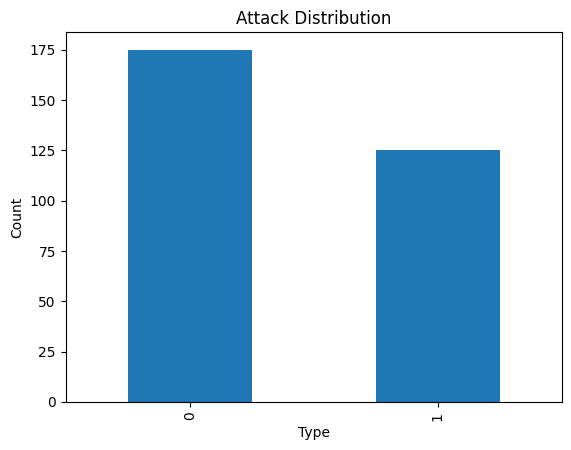

In [11]:
df1["label"].value_counts().plot(kind="bar")
plt.title("Attack Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

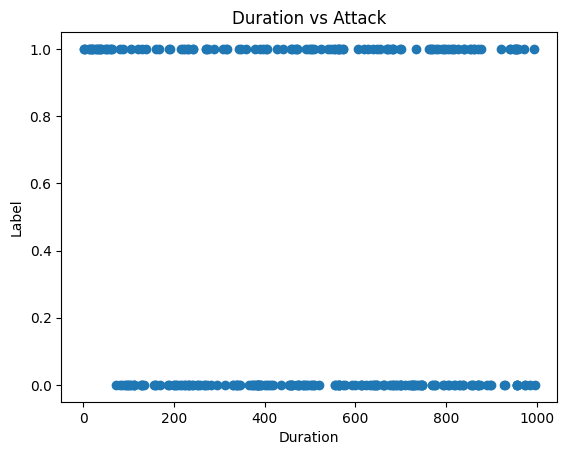

In [13]:
plt.scatter(df1["duration"], df1["label"])
plt.title("Duration vs Attack")
plt.xlabel("Duration")
plt.ylabel("Label")
plt.show()

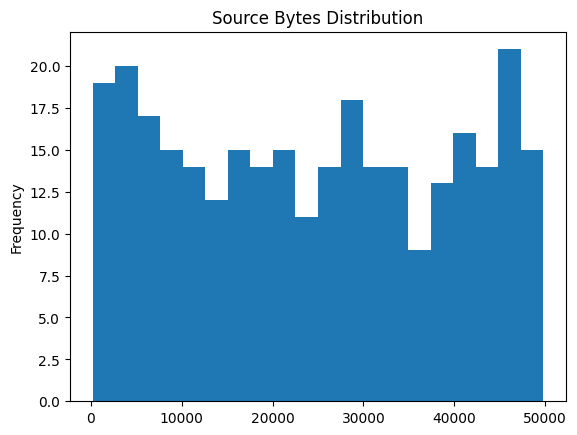

In [14]:
df1["src_bytes"].plot(kind="hist", bins=20)
plt.title("Source Bytes Distribution")
plt.show()

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "duration": np.random.randint(0, 1000, 300),
    "src_bytes": np.random.randint(0, 50000, 300),
    "dst_bytes": np.random.randint(0, 50000, 300),
})

In [3]:
df["label"] = np.where(
    (df["src_bytes"] > 30000) | (df["duration"] < 50),
    "attack",
    "normal"


In [5]:
df.head()


,duration,src_bytes,dst_bytes,label
0,102,26309,23289,normal
1,435,21919,44690,normal
2,860,4931,35257,normal
3,270,32970,9823,attack
4,106,44215,41975,attack


In [6]:
df["label"].value_counts()

label
normal    175
attack    125
Name: count, dtype: int64

In [7]:
df["label"] = df["label"].map({"normal": 0, "attack": 1})

In [8]:
X = df[["duration", "src_bytes", "dst_bytes"]]
y = df["label"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9833333333333333


In [12]:
import joblib

joblib.dump(model, "nids_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [13]:
df.to_csv("network_data.csv", index=False)